![](https://gymnasium.farama.org/_images/cliff_walking.gif)

# Reinforcement Learning
### *Cliff Walking Problem*

**Environment (`env`)**: 4 x 12 grid

**Actions**: ↑, ↓, ←, →  {0, 3}

**Rewards**:
* Normal cells → -1
* Target cell → 0
* Cliff → -100

*(**Note**: Whenever agent encounters cliff, it returns to state **S**)*

---

### State Representation
**State**: 4 * 12 = 48 cells `(row, col)`

To represent the state as a single number:
`state = row * 12 + col`

**S** (3,0) = 3*12 + 0 = 36

---

### Grid Layout

| 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 12 | 13 | 14 | 15 | 16 | 17 | 18 | 19 | 20 | 21 | 22 | 23 |
| | | | | | | | | | | | |
| **S** | **C** | **C** | **C** | **C** | **C** | **C** | **C** | **C** | **C** | **C** | **E** |

*(Note: **S** = Start, **C** = Cliff, **E** = End/Target)*

In [1]:
import gymnasium as gym
import numpy as np
import random

# Gymnasium

### `env` object
Below are the core methods associated with the environment object:

1. **create** → `make()`
2. **show** → `render()`
3. **reset** → `reset()`
4. **close** → `close()`
5. **action** → `step()`

In [2]:
# sample env
env = gym.make("CliffWalking-v1")

In [3]:
print(env.observation_space.n) #states
print(env.action_space.n) #actions

starting_state, _ = env.reset()
print(starting_state)

48
4
36


# SARSA

In [4]:
# Parameters

alpha = 0.5
gamma = 0.99
episodes = 500
epsilon = 0.1

In [5]:
# Q-table => store Q-values

Q = np.zeros((48,4))

In [6]:
# Policy - E-greedy: state -> action

def epsilon_greedy(state):
    if random.random() < epsilon:
        return env.action_space.sample() # random action => Explore
    else:
        return np.argmax(Q[state]) # Exploit

In [7]:
for episode in range(episodes):

    #rendering 
    render = (episode % 50 == 0)

    if render:
        env = gym.make("CliffWalking-v1")
        print(f"rendering env for episode= {episode+1}/{episodes}")
    else:
        env = gym.make("CliffWalking-v1")

# terminate -> agnt reached E
# truncate -> cut short (max time or max length reached)

    done = False # when episode has ended
    state, _ = env.reset()
    action = epsilon_greedy(state)

    total_reward = 0
    episode_len = 0

    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_action = epsilon_greedy(next_state)

        #SARSA update
        Q[state, action] += alpha * (reward + gamma*(Q[next_state, next_action] - Q[state, action]))

        state = next_state
        action = next_action

        total_reward += reward
        episode_len += 1

    print(f"episode= {episode+1}/{episodes}: total reward = {total_reward} & ep length = {episode_len}")
    env.close()

        

rendering env for episode= 1/500
episode= 1/500: total reward = -70 & ep length = 70
episode= 2/500: total reward = -2271 & ep length = 588
episode= 3/500: total reward = -144 & ep length = 144
episode= 4/500: total reward = -424 & ep length = 127
episode= 5/500: total reward = -207 & ep length = 108
episode= 6/500: total reward = -167 & ep length = 68
episode= 7/500: total reward = -304 & ep length = 106
episode= 8/500: total reward = -72 & ep length = 72
episode= 9/500: total reward = -43 & ep length = 43
episode= 10/500: total reward = -223 & ep length = 124
episode= 11/500: total reward = -35 & ep length = 35
episode= 12/500: total reward = -37 & ep length = 37
episode= 13/500: total reward = -70 & ep length = 70
episode= 14/500: total reward = -58 & ep length = 58
episode= 15/500: total reward = -36 & ep length = 36
episode= 16/500: total reward = -37 & ep length = 37
episode= 17/500: total reward = -51 & ep length = 51
episode= 18/500: total reward = -39 & ep length = 39
episode=

In [8]:
# what did our agent learn?

env = gym.make("CliffWalking-v1")
done = False 
state, _ = env.reset()
total_reward = 0
episode_len = 0

while not done:
    action = np.argmax(Q[state])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    total_reward += reward
    episode_len += 1

print(f"total reward = {total_reward} & ep length = {episode_len}")
env.close()

total reward = -19 & ep length = 19


total reward = -19 & ep length = 19


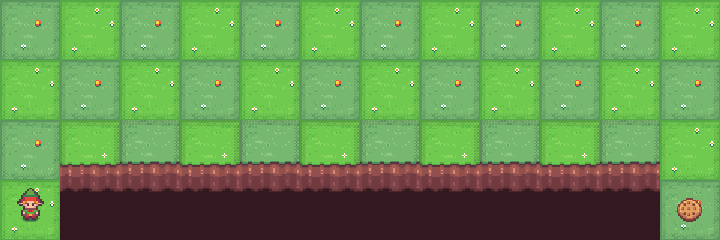

In [9]:
#visualization 

import os
# Trick PyGame into using a fake screen and fake speakers
os.environ['SDL_VIDEODRIVER'] = 'dummy'
os.environ['SDL_AUDIODRIVER'] = 'dummy'

import imageio
from IPython.display import Image, display

# 1. Create the environment
env = gym.make("CliffWalking-v1", render_mode="rgb_array")

done = False 
state, _ = env.reset()
total_reward = 0
episode_len = 0

# Create an empty list to hold our picture frames
frames = []

# Capture the very first starting frame
frames.append(env.render())

# 2. Your exact agent logic
while not done:
    action = np.argmax(Q[state])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    total_reward += reward
    episode_len += 1
    
    # Capture a new frame after every single step
    frames.append(env.render())

print(f"total reward = {total_reward} & ep length = {episode_len}")
env.close()

# 3. Save the collected frames as a GIF
gif_path = "cliff_walking_agent.gif"
# fps=10 means 10 frames per second. You can increase it to make the agent move faster!
imageio.mimsave(gif_path, frames, fps=10, loop=0)

# 4. Display the GIF right here in the notebook
display(Image(filename=gif_path))